In [1]:
from vrae.vrae import VRAE
from vrae.utils import *
import time
import shutil
import numpy as np
import torch
import torch.nn as nn   
import pandas as pd
import plotly
from torch.utils.data import DataLoader, TensorDataset
plotly.offline.init_notebook_mode()
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

def last_noNaN_index(serie):
    return((~np.isnan(serie.flatten())).cumsum(0).argmax(0))

def first_NaN_index(serie):
    return(np.where(np.isnan(serie))[0][0] if np.sum(np.isnan(serie))>0 else len(serie))

df = pd.read_pickle(fr'C:\Users\achfr\OneDrive - University of Edinburgh\Compiled dataset\df_compiled_mothers_labelled_cyclefate.csv')
df_tracks= df.pivot(values=[
    'GrowthRateSize','GrowthRateLength','GrowthRateFeretMax','GrowthRateFeretMaxSliding',
    'InterdivisionTimes','DivisionRate','DivisionRate_filtered','TrackLength','TrackLength_filtered',
    'Size','SizeAtBirthSize','FeretMax','SizeAtBirthFeretMax','MaxLength','SpineLength','SizeAtBirthLength','SpineWidth',
    'MeanIntensity_mch','MeanIntensity_gfp','Maxgfp',
    'BacteriaLineage','NextDivisionFrame','PreviousDivisionFrame',
    'TrackHeadIndices','Prev','Next','Idx','Frame','Indices','PositionIdx','cellcycle_fate'], 
    index=['Position','ParentTrackHeadIndices','Medium','Treatment','RepeatID','RepeatDate','fate','DeathSubtype'],
    columns='Time')

X_train shape	 (32706, 96, 1) 	 X_test shape	 (583, 96, 1)


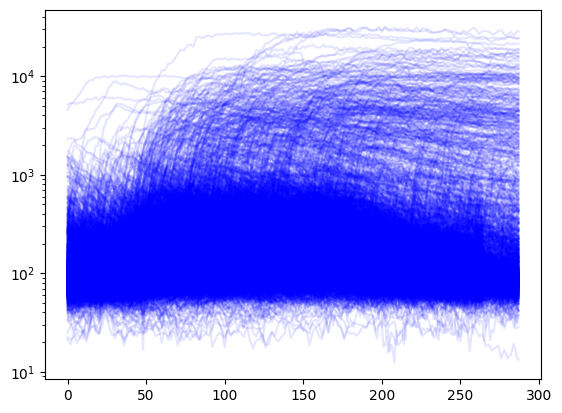

In [2]:
#### Creating dataset and splitting it into train and test sets then data augmentation
liste_x=[]
liste_y=[]

dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1']

for exp_name in dataset_name_list:

    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
    sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
    mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

    DeathSubtype = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])

    for i in range(size_array.shape[0]):
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        size_serie =  size_array[i]
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

        sos_serie = sos_array[i]
        for j in range(1,len(sos_serie)-1):
            if np.isnan(sos_serie[j]):
                sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
        mcherry_serie = mcherry_array[i]
        for j in range(1,len(mcherry_serie)-1):
            if np.isnan(mcherry_serie[j]):
                mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

        cyclefate_serie = cyclefate_array[i]
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
        first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

        if first_NaN>96:
            last_usable_timepoint = min(first_NaN,288)
            liste_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
            liste_y.append((medium,treatment,replicate,t_death,DeathSubtype[i]))
#scan for NANs in all liste_x
for x in liste_x:
    for serie in x:
        if np.sum(np.isnan(serie))>0:
            print('NAN found')

X_train_preaug, X_test_preaug, y_train_preaug, y_test_preaug = train_test_split(liste_x, liste_y, test_size=0.1, random_state=42, shuffle=True)
#### data augmentation
##### in X_train we change each sequence to series of size 96 with a roling window of 12
liste_x_train = []
liste_y_train = []
for i in range(len(X_train_preaug)):
    usable_data = X_train_preaug[i][1] #using only the SOS signal
    for j in range(0, len(usable_data) - 96 + 1, 12):
        liste_x_train.append(usable_data[j:j+96])
        liste_y_train.append(y_train_preaug[i])
X_train = TimeSeriesScalerMeanVariance().fit_transform(np.log(np.array(liste_x_train)))
y_train = np.array(liste_y_train)

# In X_test we cut each sequence into unique 96-long sequences
liste_x_test = []
liste_y_test = []
for i in range(len(X_test_preaug)):
    usable_data = X_test_preaug[i][1]
    for j in range(0, len(usable_data) - 96 + 1, 96):
        liste_x_test.append(usable_data[j:j + 96])
        liste_y_test.append(y_test_preaug[i])
X_test = TimeSeriesScalerMeanVariance().fit_transform(np.log(np.array(liste_x_test)))
y_test = np.array(liste_y_test)

train_dataset = TensorDataset(torch.from_numpy(X_train).to('cuda'))
test_dataset = TensorDataset(torch.from_numpy(X_test))

for s  in  [x[1] for x in liste_x]:
    plt.plot(s,alpha=0.1,color='blue')
plt.yscale('log')



print('X_train shape\t',X_train.shape,'\t X_test shape\t',X_test.shape)

In [3]:
## train cell with test
# replicate = 2
# t0 = time.time()

# sequence_length = X_train.shape[1]
# number_of_features = X_train.shape[2]

# dload = './model_dir_mm' #download directory
# hidden_size = 90
# hidden_layer_depth = 2
# batch_size = 200
# learning_rate = 0.001 # 0.0005
# n_epochs = 200
# dropout_rate = 0.2
# optimizer = 'Adam' # options: ADAM, SGD
# cuda = True # options: True, False
# print_every=1000
# clip = True # options: True, False
# max_grad_norm=5
# loss = 'MSELoss' # options: SmoothL1Loss, MSELoss
# block = 'LSTM' # options: LSTM, GRU


# for latent_length in range(20,2-1,-1):
#     print('latent_length\t',latent_length,'\t elapsed time\t',(time.time()-t0)/60,' minutes\t',(time.time()-t0)/3600.0,' hours')

#     vrae = VRAE(sequence_length=sequence_length,
#                 number_of_features = number_of_features,
#                 hidden_size = hidden_size, 
#                 hidden_layer_depth = hidden_layer_depth,
#                 latent_length = latent_length,
#                 batch_size = batch_size,
#                 learning_rate = learning_rate,
#                 n_epochs = n_epochs,
#                 dropout_rate = dropout_rate,
#                 optimizer = optimizer, 
#                 cuda = cuda,
#                 print_every=print_every, 
#                 clip=clip, 
#                 max_grad_norm=max_grad_norm,
#                 loss = loss,
#                 block = block,
#                 dload = dload)

#     vrae.fit(train_dataset, test_dataset, save=True)

#     file = open(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\print.txt').readlines()
#     train_losses = []
#     test_losses = []
#     for line in file:
#         if 'Average loss' in line:
#             train_losses.append(float(line.split(' ')[-2]))
#             test_losses.append(float(line.split(' ')[-1][:-2]))
#             # print(float(line.split(' ')[-2]),float(line.split(' ')[-1][:-2]))

#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\model_{replicate}_{latent_length}.pth')
#     shutil.move(fr'C:\Users\achfr\timeseries-clustering-vae\model_dir_mm\model_best.pth', fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\model_best_{replicate}_{latent_length}.pth')
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\train_losses_{replicate}_{latent_length}.npy', train_losses)
#     np.save(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\test_losses_{replicate}_{latent_length}.npy', test_losses)
# ###277m 4h37

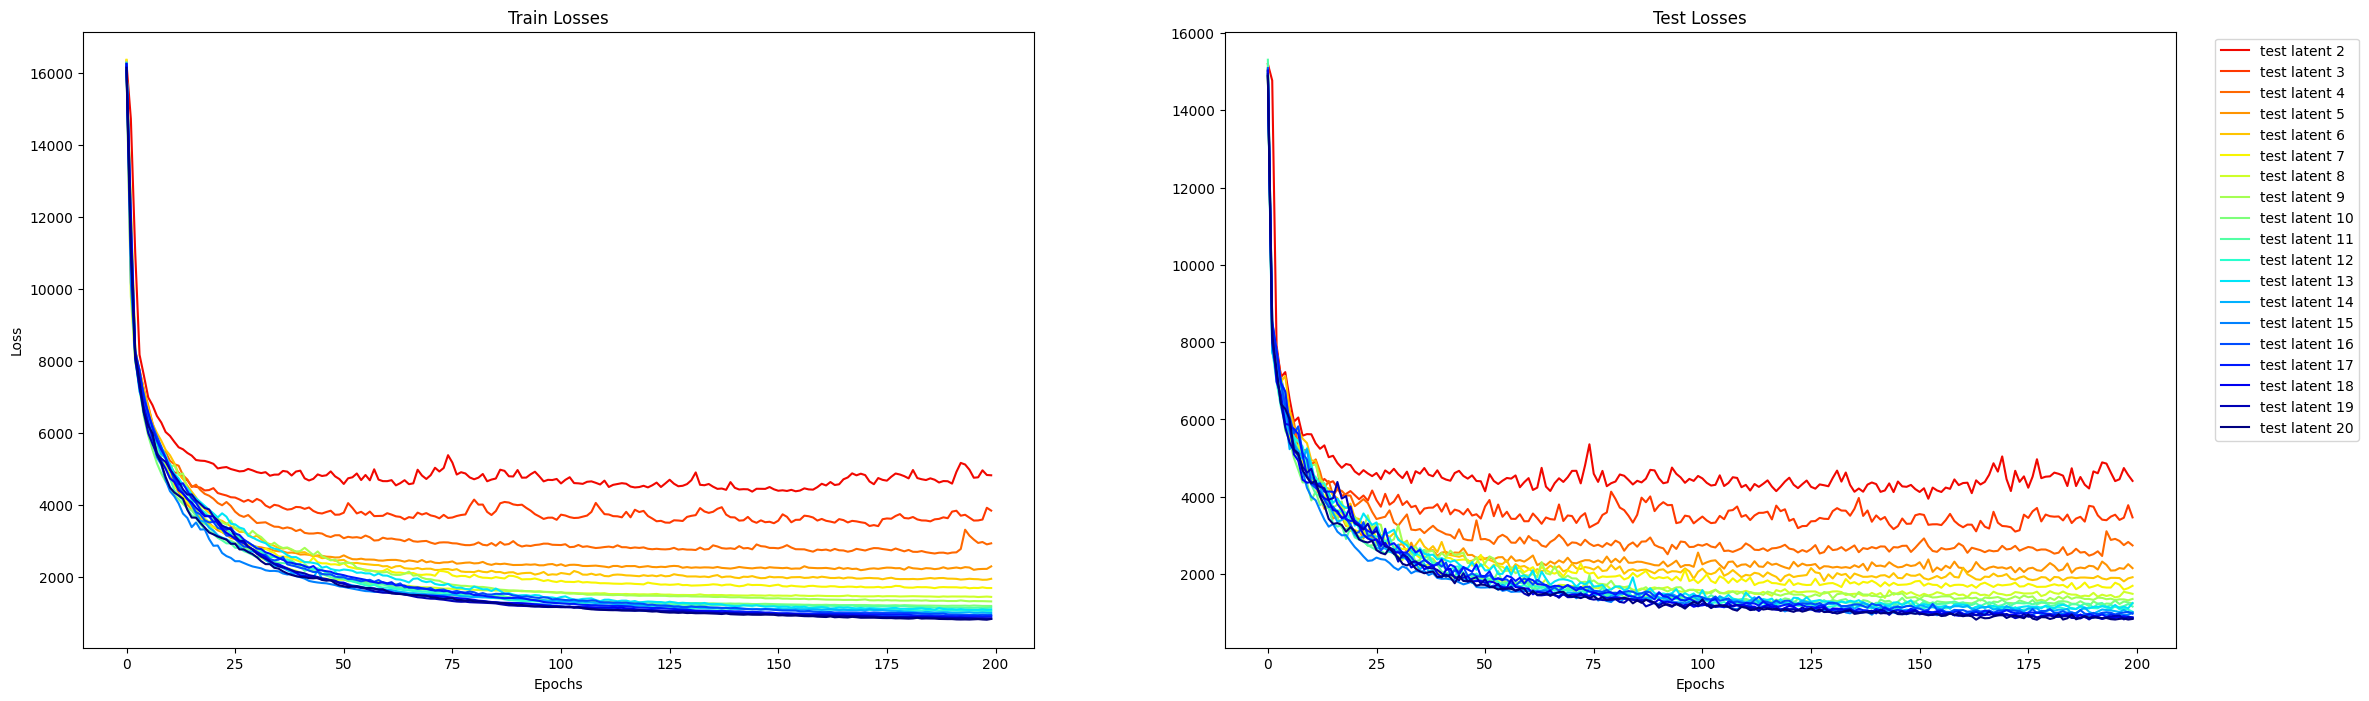

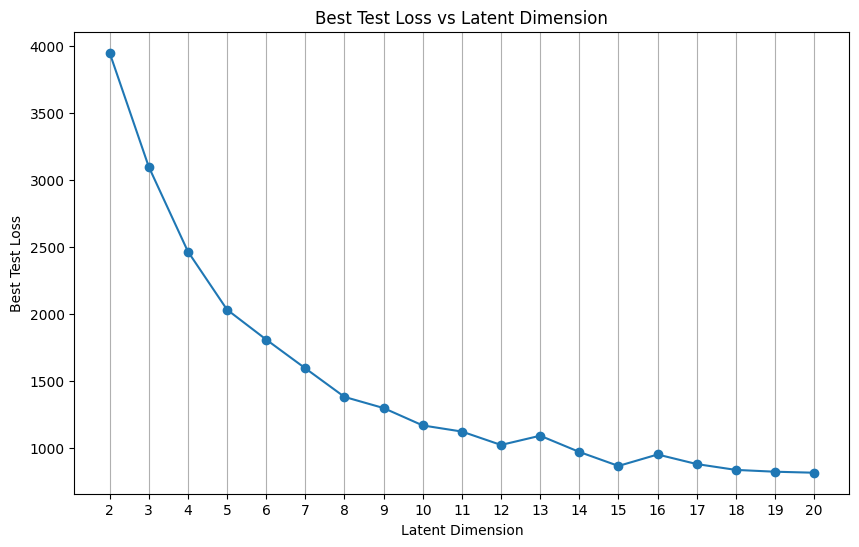

In [4]:
#### Plot loss curves for all latent dimensions
losslist=[]
meanlosslist=[]
n_replicate = 2
path = fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos'
fig,ax = plt.subplots(1,2,figsize=(27,8))
cmap = plt.get_cmap('jet')
for latent_length in range(2,20+1):
    sum_train_losses = np.zeros(200)
    sum_test_losses = np.zeros(200)
    for replicate in range(n_replicate):
        train_losses = np.load(fr'{path}\train_losses_{replicate}_{latent_length}.npy')
        test_losses = np.load(fr'{path}\test_losses_{replicate}_{latent_length}.npy')
        losslist.append((train_losses, test_losses))
        sum_train_losses += train_losses
        sum_test_losses += test_losses
    mean_train_losses = sum_train_losses/(n_replicate)
    mean_test_losses = sum_test_losses/(n_replicate)
    meanlosslist.append((mean_train_losses,mean_test_losses))
    ax[0].plot(mean_train_losses,label=f'train latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[1].plot(mean_test_losses,label=f'test latent {latent_length}', color=cmap((20-latent_length)/20))
    ax[0].set_title('Train Losses')
    ax[1].set_title('Test Losses')
    ax[0].set_xlabel('Epochs')
    ax[1].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))

# plot best test loss as a function of latent dimension
best_test_loss = []
for latent_length in range(2, 21):
    best_loss = np.min(meanlosslist[latent_length-2][1])
    best_test_loss.append(best_loss)
plt.figure(figsize=(10,6))
plt.plot(range(2, 21), best_test_loss, marker='o')
plt.xticks(range(2, 21))
plt.title('Best Test Loss vs Latent Dimension')
plt.xlabel('Latent Dimension')
plt.ylabel('Best Test Loss')
#only vertical grid
plt.grid(axis='x')
plt.show()


c:\Users\achfr\.conda\envs\mlp\lib\site-packages\torch\nn\_reduction.py:42: UserWarning:

size_average and reduce args will be deprecated, please use reduction='sum' instead.



92
124


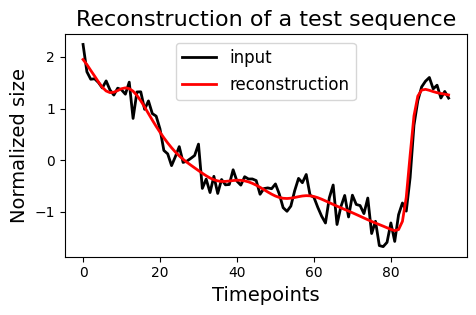

In [5]:
sequence_length = X_train.shape[1]
number_of_features = X_train.shape[2]

dload = './model_save' #model save directory
latent_length = 15
hidden_size = 90
hidden_layer_depth = 2
batch_size = 200
learning_rate = 0.001
n_epochs = 2 #200
dropout_rate = 0.2
optimizer = 'Adam'
cuda = True
print_every=1000
clip = True
max_grad_norm=5
loss = 'MSELoss'
block = 'LSTM'

vrae_trained = VRAE(sequence_length=sequence_length,
        number_of_features = number_of_features,
        hidden_size = hidden_size, 
        hidden_layer_depth = hidden_layer_depth,
        latent_length = latent_length,
        batch_size = batch_size,
        learning_rate = learning_rate,
        n_epochs = n_epochs,
        dropout_rate = dropout_rate,
        optimizer = optimizer, 
        cuda = cuda,
        print_every=print_every, 
        clip=clip, 
        max_grad_norm=max_grad_norm,
        loss = loss,
        block = block,
        dload = dload)

vrae_trained.load(fr'C:\Users\achfr\timeseries-clustering-vae\latent_result_sos\model_best_0_{latent_length}.pth')

vrae_trained.eval()
testseq2 = test_dataset[:batch_size][0].float().permute(1, 0, 2).cuda()
outp = vrae_trained.forward(testseq2)

k=np.random.randint(0,batch_size)
print(k)
k=np.random.randint(0,batch_size)
print(k)
input_seq = testseq2[:,k,0].cpu().detach().numpy()
output_seq = outp[0][:,k,0].cpu().detach().numpy()

plt.figure(figsize=(5,13/4))
plt.plot(input_seq.T, color ='black',linewidth = 2, label='input')
plt.plot(output_seq.T, color='red',linewidth = 2, label='reconstruction')
plt.xlabel('Timepoints', fontsize=14)
plt.ylabel('Normalized size', fontsize=14)
plt.title('Reconstruction of a test sequence', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

Total dataset size	 8185


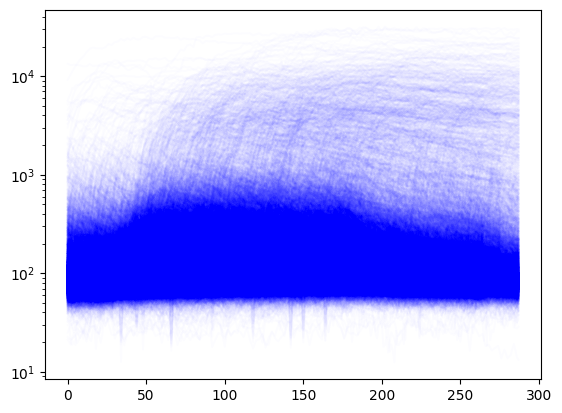

In [27]:
#### import literally everything
all_data_x=[]
all_data_y=[]

# dataset_name_list = ['gly_control_1','glu_control_1','gluaa_control_1','gly_cip_1','glu_cip_1','gluaa_cip_1','gly_ciptet_1','glu_ciptet_1','gluaa_ciptet_1'] training set
dataset_name_list = ['gly_control_1', 'gly_control_2', 'gly_control_3', 'gly_cip_1', 'gly_cip_2', 'gly_tet_1', 'gly_tet_2', 'gly_tet_3', 'gly_ciptet_1', 'gly_ciptet_2', 'glu_control_1', 'glu_control_2', 'glu_cip_1', 'glu_cip_2', 
 'glu_tet_1', 'glu_tet_2', 'glu_ciptet_1', 'glu_ciptet_2', 'gluaa_control_1', 'gluaa_control_2', 'gluaa_cip_1', 'gluaa_cip_2', 'gluaa_cip_3', 'gluaa_tet_1', 'gluaa_tet_2', 'gluaa_ciptet_1', 'gluaa_ciptet_2']


for exp_name in dataset_name_list:

    medium,treatment,replicate = exp_name.split('_')

    frame = df_tracks.loc(axis=0)[:,:,medium,treatment,replicate]
    
    size_array = np.array([list(frame['FeretMax'].T[k]) for k in frame['FeretMax'].T.keys()])
    cyclefate_array = np.array([list(frame['cellcycle_fate'].T[k]) for k in frame['cellcycle_fate'].T.keys()])
    sos_array = np.array([list(frame['MeanIntensity_gfp'].T[k]) for k in frame['MeanIntensity_gfp'].T.keys()])
    mcherry_array = np.array([list(frame['MeanIntensity_mch'].T[k]) for k in frame['MeanIntensity_mch'].T.keys()])

    DeathSubtypes = np.array([i for i in frame.reset_index('DeathSubtype')['DeathSubtype']])
    Fates = np.array([i for i in frame.reset_index('fate')['fate']])

    for i in range(size_array.shape[0]):
        ##fill nans missing timepoints with the mean of the previous and next timepoints
        size_serie =  size_array[i]
        for j in range(1,len(size_serie)-1):
            if np.isnan(size_serie[j]):
                size_serie[j] = np.mean([size_serie[j-1],size_serie[j+1]])

        sos_serie = sos_array[i]
        for j in range(1,len(sos_serie)-1):
            if np.isnan(sos_serie[j]):
                sos_serie[j] = np.mean([sos_serie[j-1],sos_serie[j+1]])
                
        mcherry_serie = mcherry_array[i]
        for j in range(1,len(mcherry_serie)-1):
            if np.isnan(mcherry_serie[j]):
                mcherry_serie[j] = np.mean([mcherry_serie[j-1],mcherry_serie[j+1]])

        cyclefate_serie = cyclefate_array[i]
        for j in range(len(cyclefate_serie)-1):
            if cyclefate_serie[j] == 'nan':
                cyclefate_serie[j] = cyclefate_serie[j+1]

        t_death = len(cyclefate_serie)
        if np.where(cyclefate_serie != 'alive')[0].shape[0] > 0:
            t_death = np.where(cyclefate_serie != 'alive')[0][0]

        # last_usable_timepoint = np.min([last_noNaN_index(size_serie),last_noNaN_index(sos_serie),last_noNaN_index(mcherry_serie)])
        first_NaN = np.min([first_NaN_index(size_serie),first_NaN_index(sos_serie),first_NaN_index(mcherry_serie)])

        if first_NaN>96:
            last_usable_timepoint = min(first_NaN,288)
            all_data_x.append((size_serie[:last_usable_timepoint],sos_serie[:last_usable_timepoint],mcherry_serie[:last_usable_timepoint]))
            all_data_y.append((medium,treatment,replicate,t_death,DeathSubtypes[i],Fates[i]))
#scan for NANs in all all_data_x
for x in all_data_x:
    for serie in x:
        if np.sum(np.isnan(serie))>0:
            print('NAN found')

# pad data with NaNs to make them all the same length, then log and scale then cut them back to original length
max_length = max([x[1].shape[0] for x in all_data_x])
padded_data = np.array([np.pad(x[1], (0, max_length - x[1].shape[0]), mode='constant', constant_values=np.NaN) for x in all_data_x])
padded_data_scaled = TimeSeriesScalerMeanVariance().fit_transform(np.log(padded_data))

all_data_x_sos_scaled = [padded_data_scaled[i][:all_data_x[i][1].shape[0]] for i in range(len(all_data_x))]

for s  in  [x[1] for x in all_data_x]:
    plt.plot(s,alpha=0.01,color='blue')
plt.yscale('log')
print('Total dataset size\t',len(all_data_x))
#1m48

In [55]:
## isolate sequences which have massive drops
nbseq={}
seqlist={}
for drop in range(100,2000,100):
    print('drop\t',drop)
    selected_sequences = []
    for i in range(len(all_data_x)):
        s = all_data_x[i][1]
        for j in range(1,len(s)):
            if s[j-1]-s[j]>drop: #drop of more than 100 in one timepoint
                selected_sequences.append(s)
                break
    nbseq[drop] = len(selected_sequences)
    seqlist[drop] = selected_sequences

drop	 100
drop	 200
drop	 300
drop	 400
drop	 500
drop	 600
drop	 700
drop	 800
drop	 900
drop	 1000
drop	 1100
drop	 1200
drop	 1300
drop	 1400
drop	 1500
drop	 1600
drop	 1700
drop	 1800
drop	 1900


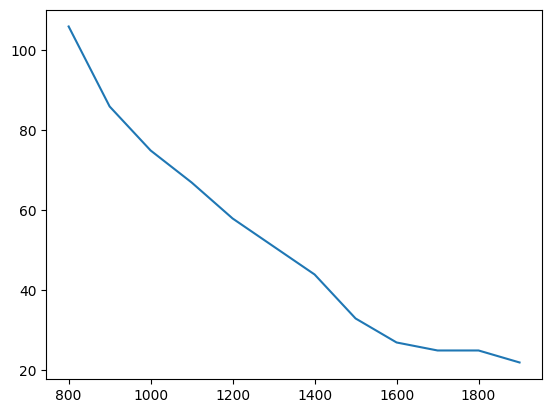

In [47]:
plt.plot(range(800,2000,100),nbseq.values())

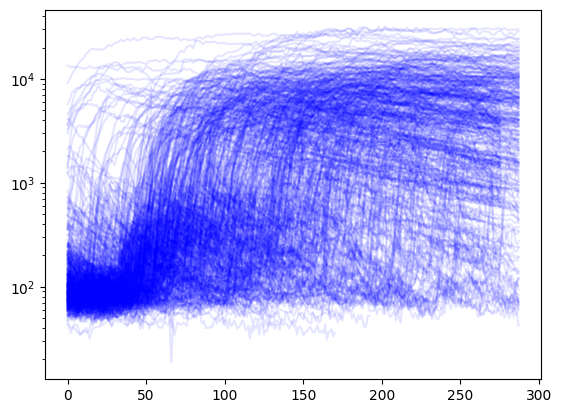

In [58]:
for x in seqlist[300]:
    plt.plot(x,alpha=0.1,color='blue')
    plt.yscale('log')

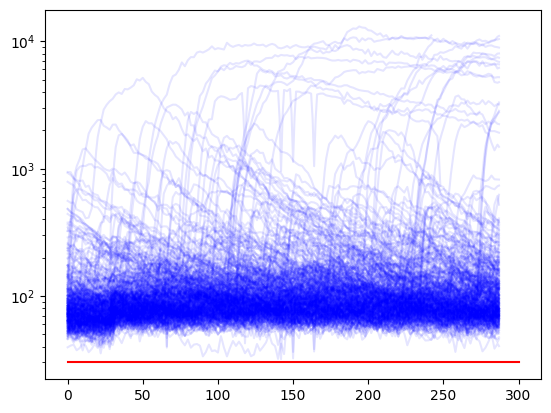

In [26]:
# for i in range(len(all_data_x)):
#     if all_data_y[i][0]+'_'+all_data_y[i][1]+'_'+all_data_y[i][2]=='gly_control_2':
#         if np.min(all_data_x[i][1]) < 20:
#             print(i)
#         plt.plot(all_data_x[i][1],color='blue',alpha=0.1)
#         plt.yscale('log')
# plt.plot((0,300),(20,20),color='red')

# remove series with SOS < 20 at any timepoint
filtered_all_data_x = []
filtered_all_data_y = []
for i in range(len(all_data_x)):
    if np.min(all_data_x[i][1]) >= 30:
        filtered_all_data_x.append(all_data_x[i])
        filtered_all_data_y.append(all_data_y[i])

all_data_x = filtered_all_data_x
all_data_y = filtered_all_data_y

for i in range(len(all_data_x)):
    if all_data_y[i][0]+'_'+all_data_y[i][1]+'_'+all_data_y[i][2]=='gly_control_2':
        if np.min(all_data_x[i][1]) < 20:
            print(i)
        plt.plot(all_data_x[i][1],color='blue',alpha=0.1)
        plt.yscale('log')
plt.plot((0,300),(30,30),color='red')

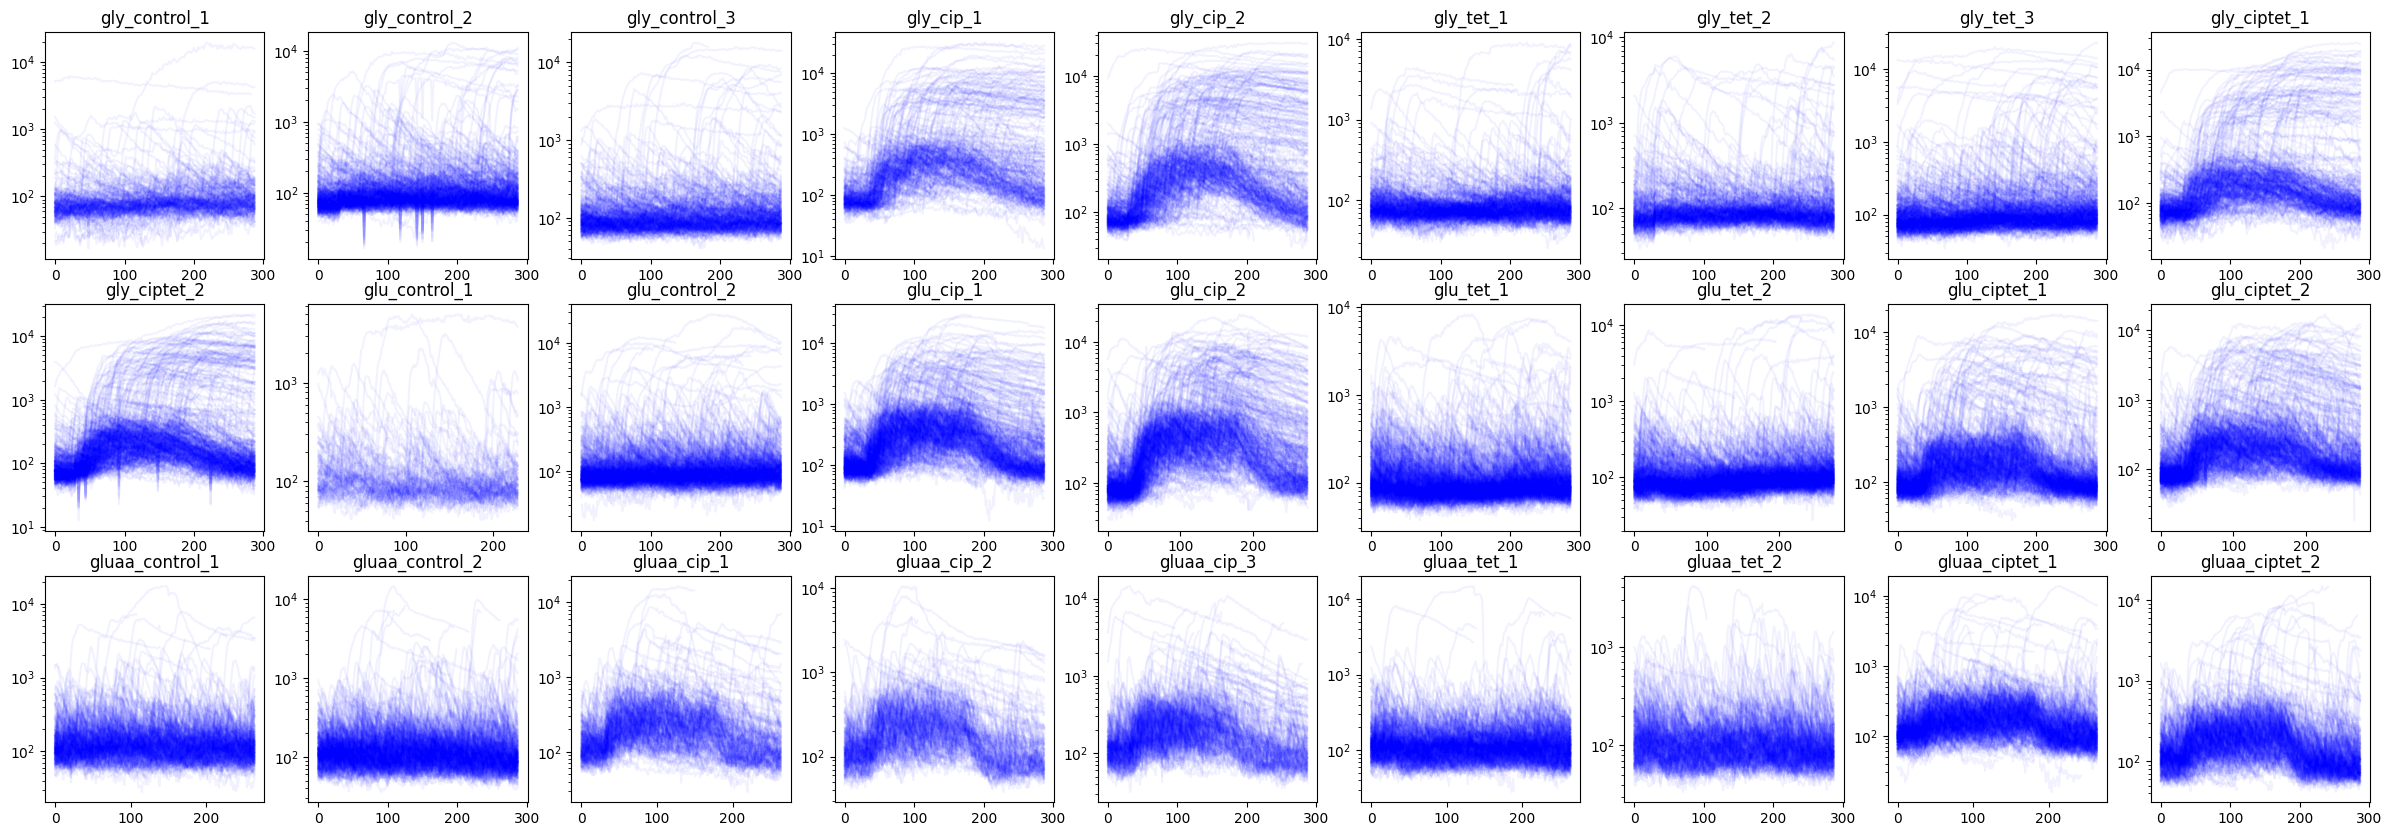

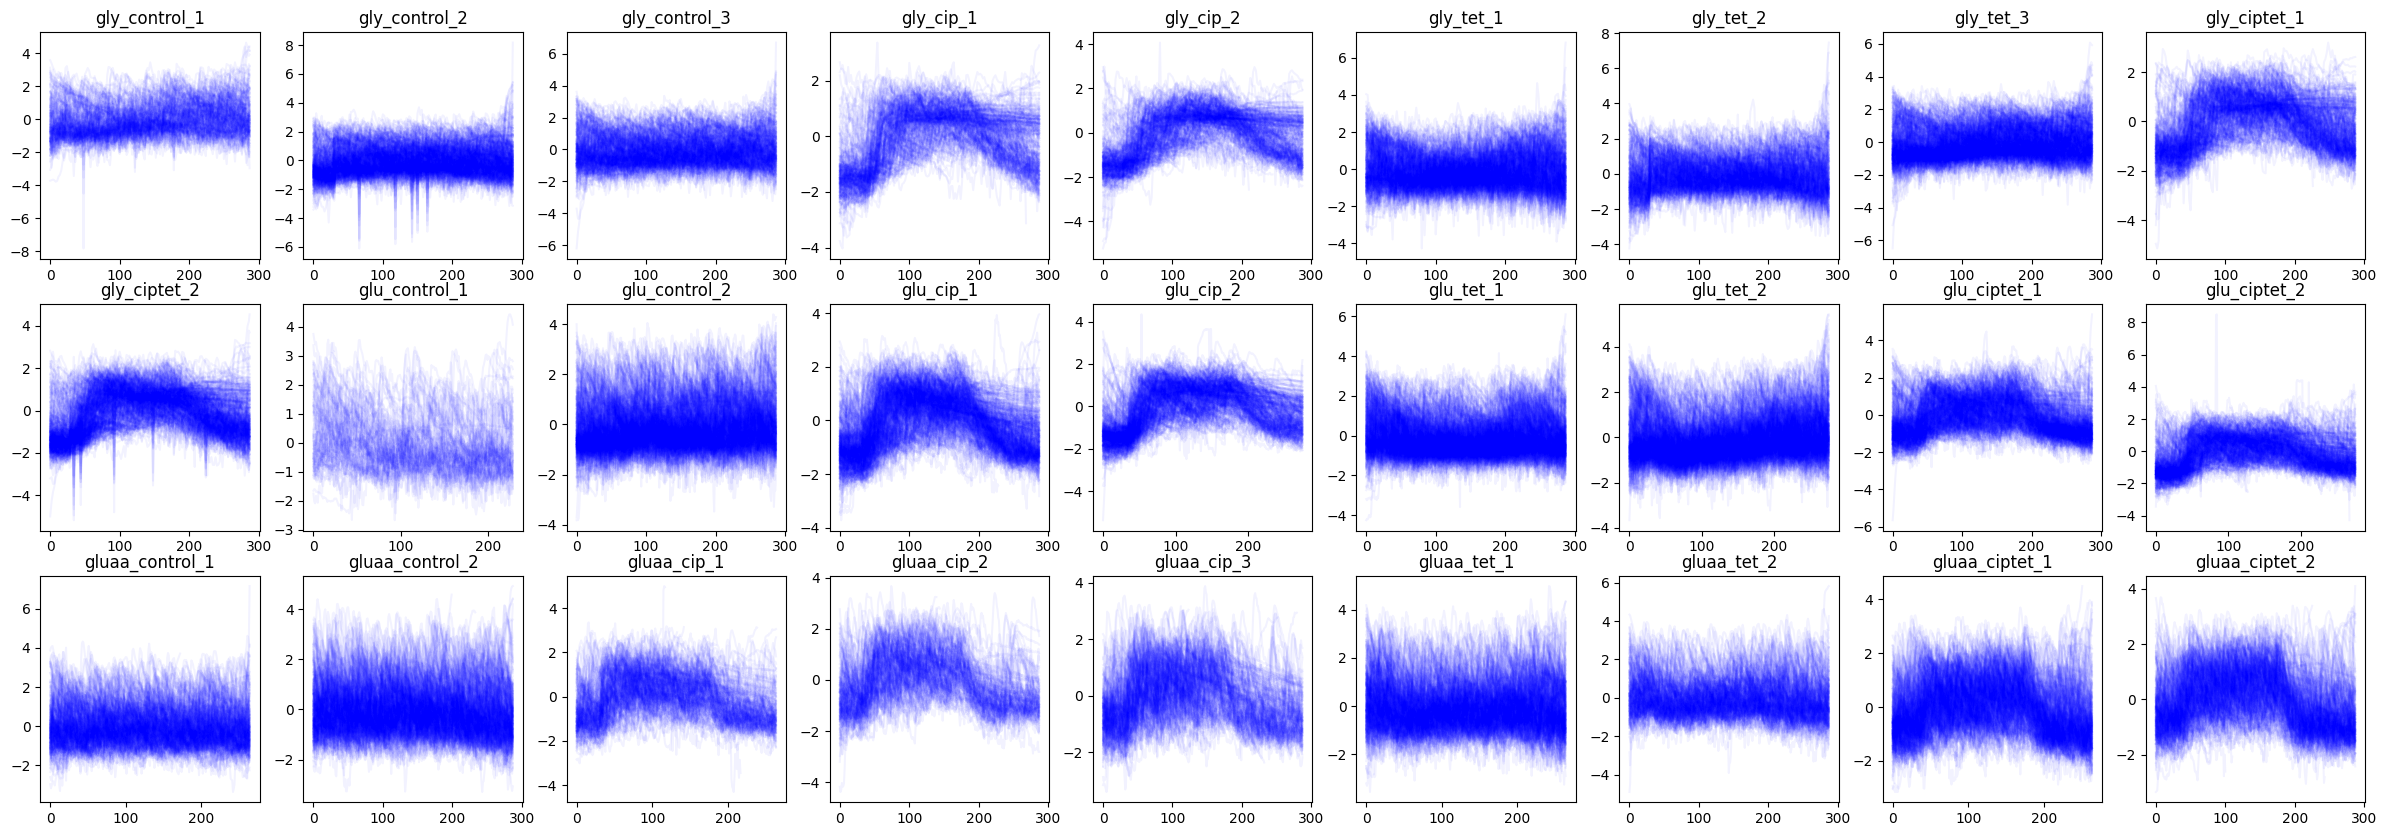

In [20]:
## data inspection after logging and scaling
fig,ax = plt.subplots(3,9,figsize=(30,10))
# ax.flatten()
for i in range(27):
    ax.flatten()[i].set_title(dataset_name_list[i])
    medium,treatment,replicate = dataset_name_list[i].split('_')
    ax.flatten()[i].plot(np.array([padded_data[j,:] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)
    ax.flatten()[i].set_yscale('log')

fig,ax = plt.subplots(3,9,figsize=(30,10))
# ax.flatten()
for i in range(27):
    ax.flatten()[i].set_title(dataset_name_list[i])
    medium,treatment,replicate = dataset_name_list[i].split('_')
    ax.flatten()[i].plot(np.array([padded_data_scaled[j,:,0] for j in range(len(all_data_y)) if all_data_y[j][0]==medium and all_data_y[j][1]==treatment and all_data_y[j][2]==replicate] ).T,color='blue',alpha=0.05)


In [8]:
# encode everything
latent_all = []
vrae_trained.eval()
vrae_trained.batch_size = 1
for x in all_data_x:
    input_seq = torch.from_numpy(np.log(x[1])).float().unsqueeze(1).unsqueeze(0).unsqueeze(0).cuda()
    latent = vrae_trained.transform(input_seq)
    latent_all.append(latent)